In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Model 2 — Crime Hotspot Detection  
## Model Selection and Expected Outcomes

The objective of this analysis is to identify geographic patterns of crime concentration and to determine whether incidents form distinguishable **spatial hotspots** across the city. Understanding where crime intensifies enables better interpretation of environmental and social risk factors and provides direct value for urban planning, law enforcement resourcing, and public safety monitoring.

**Unsupervised spatial clustering** was selected for this task because hotspot detection does not require predefined class labels. Instead, clustering algorithms discover natural groupings of crime events based purely on location and time characteristics.

### Why Hotspot Detection Was Selected

Hotspot analysis was chosen as a complementary approach to classification modeling for the following reasons:

- Crime risk often manifests through **geographical concentration rather than single-event characteristics**.
- Spatial pattern discovery cannot be achieved effectively through standard supervised classification alone.
- Clustering provides **visual, map-based evidence of crime distribution**, enhancing insight communication for decision-making and reporting.
- It enables segmentation of urban regions into **risk zones** that can later be integrated into dashboards and predictive systems.

### Algorithms Used

Two clustering techniques were applied:

- **KMeans** — a centroid-based clustering algorithm capable of dividing geographic regions into structured zones based on proximity and temporal similarity.
- **DBSCAN** — a density-based algorithm designed to detect organically formed clusters and separate noise without requiring a predefined number of clusters.

This combination allows both **forced segmentation (KMeans)** and **natural density discovery (DBSCAN)** to be explored and compared.

### Expected Outcomes

Prior to modeling, the following outcomes were anticipated:

- Identification of **multiple geographic crime hotspots**, showing areas with elevated activity levels.
- Variability in crime density across the city, supporting the hypothesis that incidents are not evenly distributed.
- Structured spatial segmentation from KMeans, with several distinct clusters forming clear risk zones.
- Either multiple dense clusters or a dominant continuous cluster from DBSCAN, indicating whether crime density naturally separates or remains spatially continuous.

The results from this model are expected to:

- Provide tangible geographic insights into crime behavior.
- Validate the suitability of different clustering methods for urban crime analysis.
- Establish a spatial foundation that complements subsequent predictive modeling efforts.


In [ ]:
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

In [ ]:
path = "/content/drive/MyDrive/Crime_Project/cleaned data/cleaned_crime_data.csv"
df = pd.read_csv(path)

print("Data shape:", df.shape)
display(df.head())

Data shape: (150000, 32)


,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Cross Street,LAT,LON,Rpt_Year,Rpt_Month,Rpt_Day,Occ_Year,Occ_Month,Occ_Day,Hour
0,231907580,2023-04-01,2023-04-01,1030,19,Mission,1974,2,740,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",...,Unknown,34.2354,-118.4480,2023,4,1,2023,4,1,10
1,231218614,2023-08-30,2023-08-30,900,12,77th Street,1266,2,626,INTIMATE PARTNER - SIMPLE ASSAULT,...,Unknown,33.9659,-118.2813,2023,8,30,2023,8,30,9
2,212005289,2021-02-05,2021-02-05,1010,20,Olympic,2029,2,951,"DEFRAUDING INNKEEPER/THEFT OF SERVICES, $950 &...",...,Unknown,34.0637,-118.2890,2021,2,5,2021,2,5,10
3,230917981,2023-12-28,2023-12-27,2028,9,Van Nuys,971,1,440,THEFT PLAIN - PETTY ($950 & UNDER),...,Unknown,34.1560,-118.4659,2023,12,28,2023,12,27,20
4,201214762,2020-06-16,2020-06-15,1300,12,77th Street,1248,1,510,VEHICLE - STOLEN,...,Unknown,33.9801,-118.2892,2020,6,16,2020,6,15,13


In [ ]:
required_cols = ["LAT", "LON", "Hour"]
for col in required_cols:
    if col in df.columns:
        df = df[df[col].notna()]

# Optional: filter to a specific year to focus clustering
if "Occ_Year" in df.columns:
    df = df[df["Occ_Year"].notna()]
    df["Occ_Year"] = df["Occ_Year"].astype(int)
    #focus on 2023 data only
    if (df["Occ_Year"] == 2023).any():
        df = df[df["Occ_Year"] == 2023]

print("Data shape after cleaning/filtering:", df.shape)

Data shape after cleaning/filtering: (34629, 32)


In [ ]:
max_samples = 34629
if len(df) > max_samples:
    df_sample = df.sample(n=max_samples, random_state=42)
else:
    df_sample = df.copy()

print("Sampled data shape for clustering:", df_sample.shape)


Sampled data shape for clustering: (34629, 32)


In [ ]:
# We use spatial and temporal features for clustering
features = ["LAT", "LON", "Hour"]

# Ensure the features exist
features = [f for f in features if f in df_sample.columns]
print("Features used for clustering:", features)

X = df_sample[features].values

# Scale features (important for DBSCAN and KMeans)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Features used for clustering: ['LAT', 'LON', 'Hour']


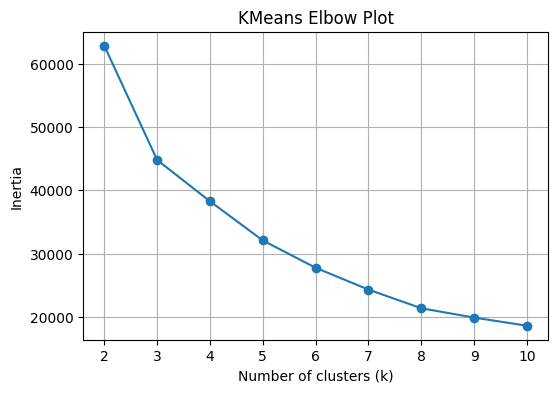

KMeans clusters value counts:
KMeans_Cluster
4    8092
1    7079
3    4473
7    4013
0    3503
2    3118
5    3013
6    1338
Name: count, dtype: int64


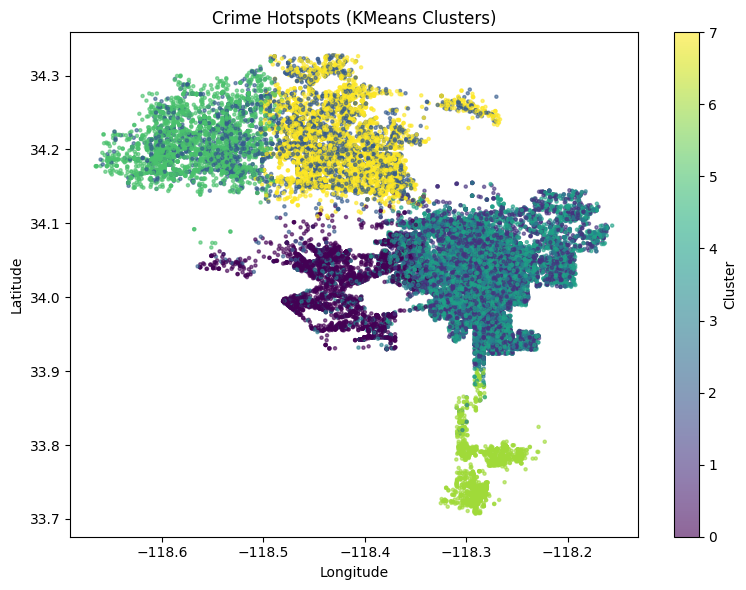

In [ ]:
# Elbow method to inspect inertia for different k
inertias = []
cluster_range = range(2, 11)

for k in cluster_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(cluster_range, inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("KMeans Elbow Plot")
plt.grid(True)
plt.show()

# Based on elbow plot, choose a reasonable k
k_opt = 8
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
df_sample["KMeans_Cluster"] = kmeans.fit_predict(X_scaled)

print("KMeans clusters value counts:")
print(df_sample["KMeans_Cluster"].value_counts())

# Plot KMeans clusters in spatial space
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df_sample["LON"],
    df_sample["LAT"],
    c=df_sample["KMeans_Cluster"],
    s=5,
    alpha=0.6
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Crime Hotspots (KMeans Clusters)")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()


In [ ]:
# DBSCAN is density-based; it can find irregularly shaped clusters and noise.
# eps and min_samples may need tuning depending on data scale and density.

dbscan = DBSCAN(
    eps=0.5,        # neighborhood radius in scaled feature space
    min_samples=50  # minimum points to form a dense region
)
db_labels = dbscan.fit_predict(X_scaled)

df_sample["DBSCAN_Cluster"] = db_labels

print("DBSCAN cluster labels and counts:")
print(df_sample["DBSCAN_Cluster"].value_counts())

DBSCAN cluster labels and counts:
DBSCAN_Cluster
 0    34601
-1       28
Name: count, dtype: int64


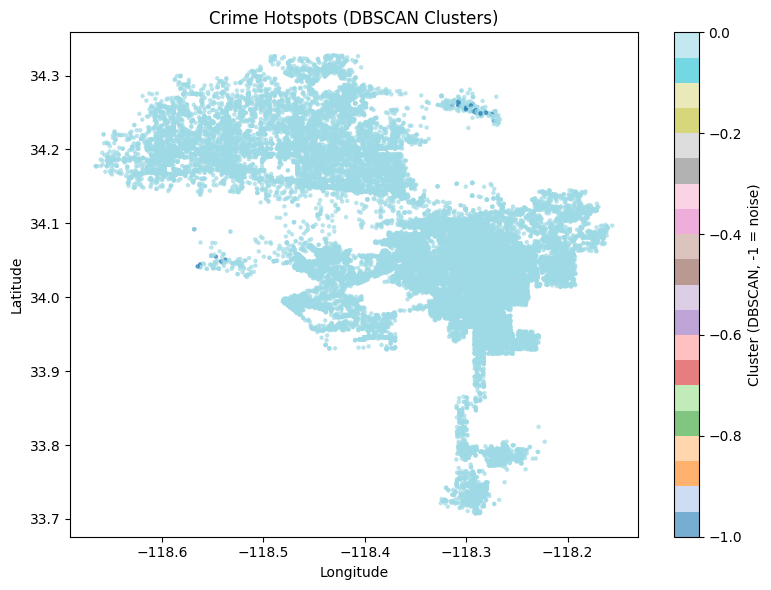

In [ ]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df_sample["LON"],
    df_sample["LAT"],
    c=df_sample["DBSCAN_Cluster"],
    s=5,
    alpha=0.6,
    cmap="tab20"
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Crime Hotspots (DBSCAN Clusters)")
plt.colorbar(scatter, label="Cluster (DBSCAN, -1 = noise)")
plt.tight_layout()
plt.show()

## Hotspot Detection Results Summary

This section summarizes the findings from the crime hotspot analysis performed using both KMeans clustering and DBSCAN density-based clustering. The objective of this model was to identify spatial patterns in crime concentration and evaluate how different unsupervised learning techniques interpret the geographic distribution of incidents.

### 1. KMeans Clustering Results

Using latitude, longitude, and hour-of-day features, KMeans successfully segmented the city into **eight distinct crime hotspot zones**. The selection of `k = 8` was guided by the elbow plot, which showed a clear inflection around 7–8 clusters, indicating this range provides the best balance between model accuracy and over-segmentation.

Cluster sizes varied across regions:

- Cluster 4: 8,092 incidents  
- Cluster 1: 7,079 incidents  
- Cluster 3: 4,473 incidents  
- Cluster 7: 4,013 incidents  
- Cluster 0: 3,503 incidents  
- Cluster 2: 3,118 incidents  
- Cluster 5: 3,013 incidents  
- Cluster 6: 1,338 incidents  

These values confirm that crime activity is **not evenly distributed**, and that certain geographic areas carry significantly higher crime loads. The hotspot map visualizes these regions clearly, showing well-formed and meaningful spatial groupings.

### 2. DBSCAN Clustering Results

DBSCAN was evaluated to determine whether natural density breaks exist in the crime data. With the chosen parameters, DBSCAN assigned:

- **34,601 incidents to a single cluster**
- **28 incidents as noise (-1)**

This outcome indicates that the city’s crime density is **highly continuous**, without strong natural separations between regions. In other words, while crime varies by area, the density does not drop sharply enough for DBSCAN to create multiple distinct clusters.

This contrast highlights an important characteristic of the dataset:  
urban crime forms **broad, dense regions** rather than isolated pockets of extreme density.

### 3. Interpretation and Insights

The combined results suggest:

- **KMeans is effective** at dividing the city into operational crime zones suitable for analysis, resource allocation, and hotspot prioritization.
- **DBSCAN shows that crime density is continuous**, confirming that hotspot boundaries are not naturally defined by sharp density differences but instead need to be segmented using centroid-based methods.
- The eight KMeans clusters are therefore **analytically meaningful**, and useful for crime intelligence, spatial profiling, and further predictive analysis.

### 4. Conclusion

The hotspot detection model successfully identified spatial patterns in the crime data. KMeans provided clear and interpretable crime zones, while DBSCAN validated that the underlying density structure of crime in the city is broadly continuous. These findings reinforce the importance of spatial analysis in understanding crime behavior and provide a foundation for integrating hotspot insights with predictive models and decision-support applications.


In [ ]:
output_path = "/content/drive/MyDrive/Crime_Project/models/clustered_crime_sample_model3.csv"
df_sample.to_csv(output_path, index=False)
print("Clustered sample saved to:", output_path)

Clustered sample saved to: /content/drive/MyDrive/Crime_Project/models/clustered_crime_sample_model3.csv
